In [ ]:
# Bibliotecas
!pip install laspy lazrs rasterio scipy matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.9/626.9 kB 23.4 MB/s eta 0:00:00


In [ ]:
# Abrindo
import laspy
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata

import rasterio
from rasterio.transform import from_origin
from PIL import Image

In [ ]:
# Abrindo LAZ - São joao abrange portugal
import laspy

las = laspy.read("/content/LO-194277-06-2024_v01.laz")

In [ ]:
# Verificando Classes
classes, counts = np.unique(
    las.classification,
    return_counts=True
)

for c, n in zip(classes, counts):
    print(f"Classe {c}: {n:,} pontos")

Classe 1: 387,803 pontos
Classe 2: 10,510,590 pontos
Classe 3: 644,390 pontos
Classe 4: 772,294 pontos
Classe 5: 2,451,969 pontos
Classe 6: 1,659,356 pontos
Classe 7: 8,922 pontos
Classe 26: 4,353 pontos


In [ ]:
# Legenda
# 1 = Não Classificado
# 2 = Solo
# 3 = Vegetação Baixa
# 4 = Vegetação Media
# 5 = Vegetação Alta
# 6 = Edificações
# 7 = Ruido
# 26 = Classe especifica do fornecedor

In [ ]:
# Filtrar somente Ground
GROUND_CLASS = 2

ground = las.classification == GROUND_CLASS

x = las.x[ground]

y = las.y[ground]

z = las.z[ground]

print(f"Pontos Ground: {len(x):,}")

Pontos Ground: 10,510,590


In [ ]:
# Criando Grid
RESOLUTION = 0.5
xmin = x.min()
xmax = x.max()

ymin = y.min()
ymax = y.max()

# Malha
grid_x, grid_y = np.mgrid[
    xmin:xmax:RESOLUTION,
    ymin:ymax:RESOLUTION
]

# Interpolação
dem = griddata(

    (x, y),

    z,

    (grid_x, grid_y),

    method="linear"
)
# Se tiver falha
mask = np.isnan(dem)

dem[mask] = griddata(

    (x, y),

    z,

    (grid_x[mask], grid_y[mask]),

    method="nearest"
)

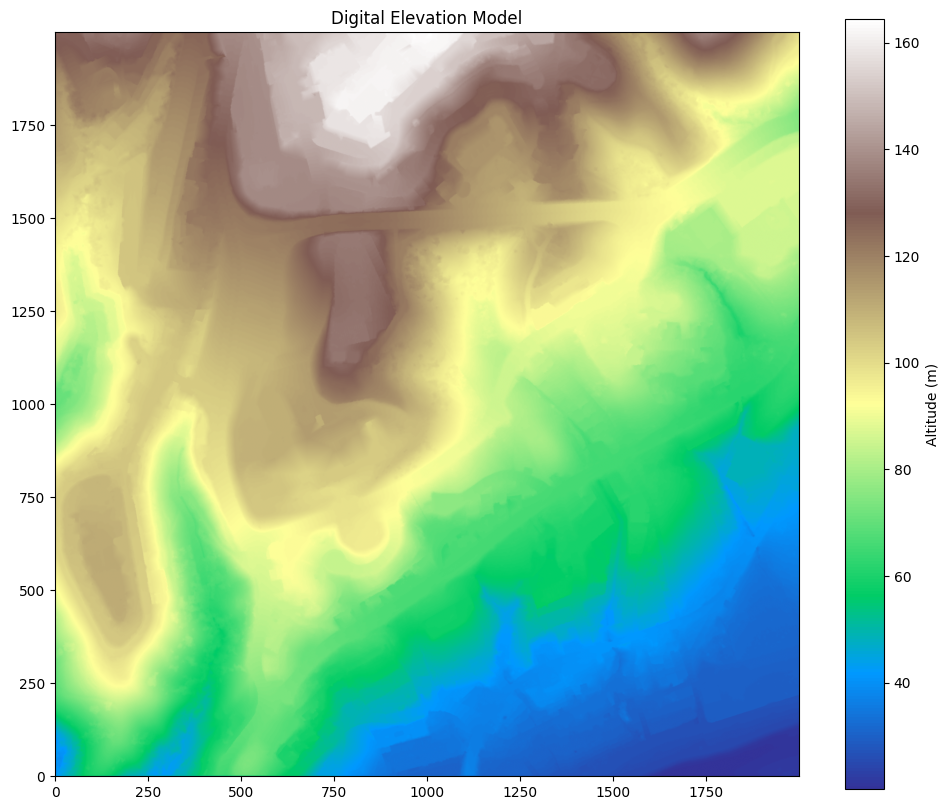

In [ ]:
# Visualização
plt.figure(figsize=(12,10))

plt.imshow(

dem.T,

origin="lower",

cmap="terrain"

)

plt.colorbar(label="Altitude (m)")

plt.title("Digital Elevation Model")
plt.savefig("DEM_lidar.png")
plt.show()

In [ ]:
# Exportar DEM
transform = from_origin(

xmin,

ymax,

RESOLUTION,

RESOLUTION

)
with rasterio.open(

"DEM_lidar.tif",

"w",

driver="GTiff",

height=dem.shape[0],

width=dem.shape[1],

count=1,

dtype=dem.dtype,

crs=las.header.parse_crs(),

transform=transform,

nodata=np.nan

) as dst:

    dst.write(dem,1)

In [ ]:
# Exportando em PNG para usar no Blender 3D
dem_norm = dem.copy()

dem_norm -= np.nanmin(dem_norm)

dem_norm /= np.nanmax(dem_norm)

dem16 = (dem_norm * 65535).astype(np.uint16)

Image.fromarray(dem16).save("DEM_16bit_lidar.png")

In [ ]:
# Estatisticas
print("Altitude mínima:", np.nanmin(dem))

print("Altitude máxima:", np.nanmax(dem))

print("Altitude média:", np.nanmean(dem))

Altitude mínima: 20.049515207599566
Altitude máxima: 164.3978996929861
Altitude média: 87.86670684798611


In [ ]:
# Hilshade
x, y = np.gradient(dem)

slope = np.pi/2 - np.arctan(np.sqrt(x*x+y*y))

aspect = np.arctan2(-x,y)

az = np.radians(315)

alt = np.radians(45)

hillshade = (

np.sin(alt)

*

np.sin(slope)

+

np.cos(alt)

*

np.cos(slope)

*

np.cos(az-aspect)

)

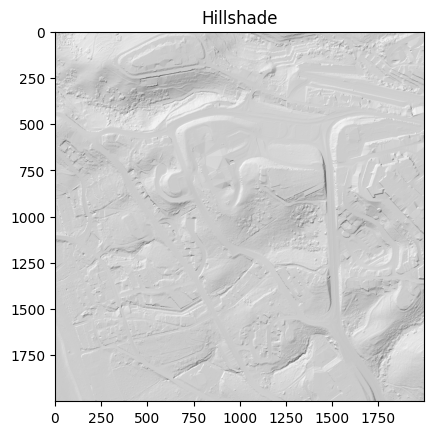

In [ ]:
plt.imshow(hillshade, cmap='gray')
plt.title("Hillshade")
plt.savefig("Hillshade_lidar.png")
plt.show()

In [ ]:
# Declividade
dx,dy=np.gradient(dem)

slope=np.degrees(

np.arctan(

np.sqrt(dx**2+dy**2)

)

)

In [ ]:
# Aspect mapa mais bonito
aspect=np.degrees(

np.arctan2(

dy,

-dx

)

)

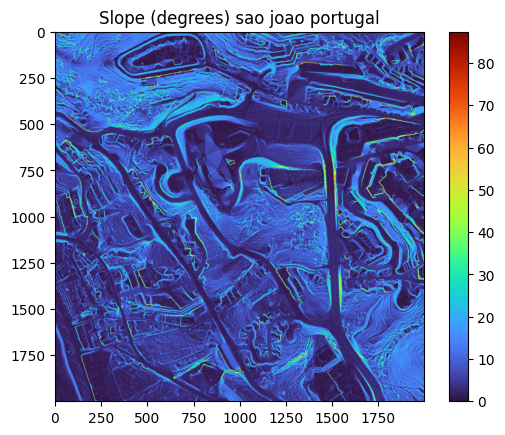

In [ ]:
# Visualização
plt.imshow(

slope,

cmap="turbo"   # 'inferno','terrain','gist_rainbow','turbo'

)

plt.colorbar()
plt.savefig("Slope_lidar.png")
plt.title("Slope (degrees) sao joao portugal")
plt.show()

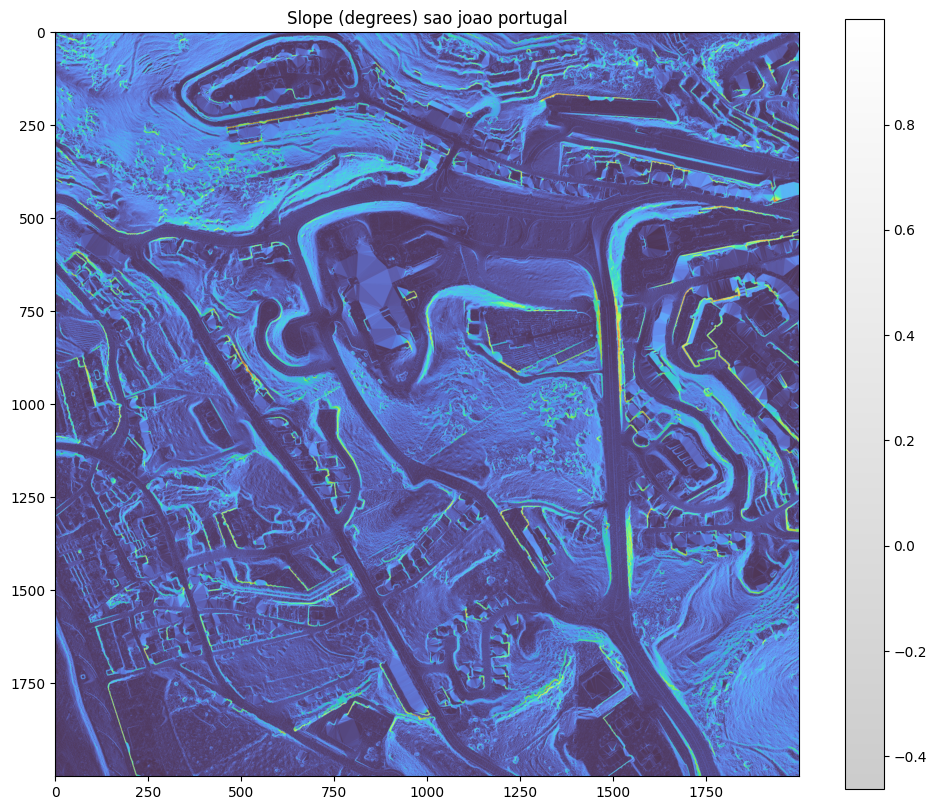

In [ ]:
# Slope e Hilshade plotados juntos
plt.figure(figsize=(12,10))

plt.imshow(slope,cmap="turbo")

plt.imshow(hillshade,cmap="gray",alpha=0.2)

plt.colorbar()
plt.title("Slope (degrees) sao joao portugal")
plt.savefig("Slope_Hillshade_lidar.png")

plt.show()

In [ ]:
# Curvature - mede como a superficie do terreno muda - positiva: terreno convexo (topos,cristas) negativo: terreno concavo (vales,depressoes), proximas de zero plana

# Primeiras derivadas
dx, dy = np.gradient(dem)

# Segundas derivadas
dxx, dxy = np.gradient(dx)
dyx, dyy = np.gradient(dy)

# Curvatura (Laplaciano)
curvature = dxx + dyy

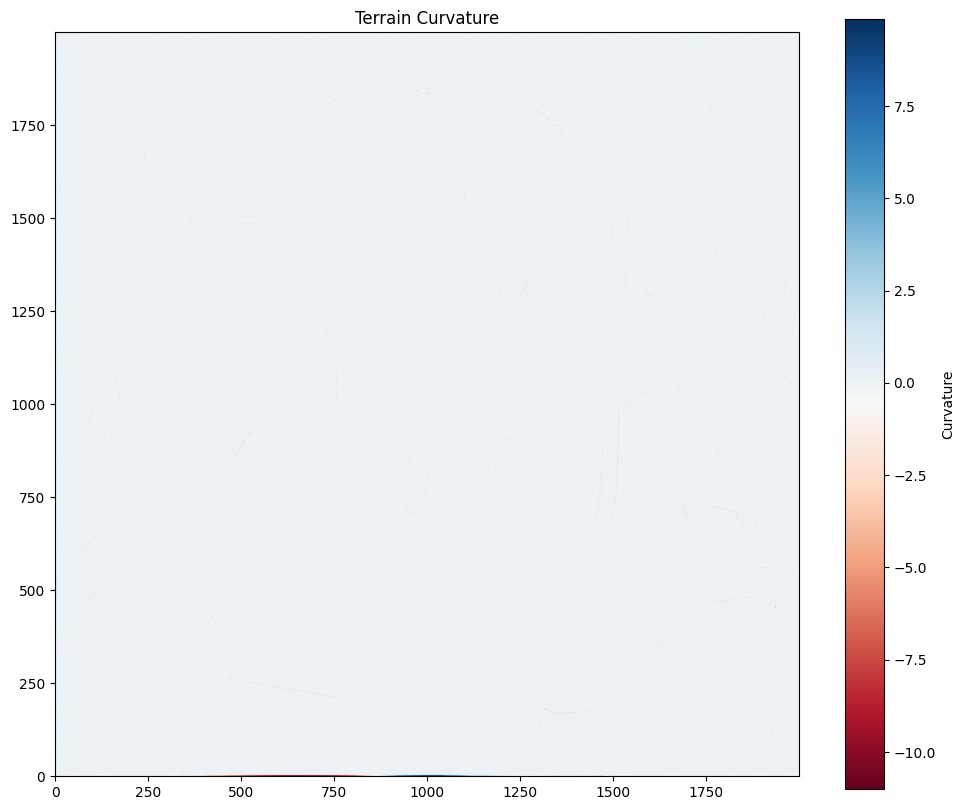

In [ ]:
# Visualizando
plt.figure(figsize=(12,10))

plt.imshow(
    curvature,
    cmap="RdBu",
    origin="lower"
)

plt.colorbar(label="Curvature")

plt.title("Terrain Curvature")

plt.show()

OU SEJA PRETICAMENTE PLANA

In [ ]:
# Exportação
profile = {
    'driver': 'GTiff',
    'height': slope.shape[0],
    'width': slope.shape[1],
    'count': 1,
    'dtype': slope.dtype,
    'crs': las.header.parse_crs(),
    'transform': transform,
    'nodata': np.nan
}

with rasterio.open(

"Slope_lidar.tif",

"w",

**profile

) as dst:

    dst.write(slope,1)

In [ ]:
# Exportando slope com hilshade em png

# Normalize hillshade to be in the range [0, 1] for alpha channel
hillshade_norm = (hillshade - np.min(hillshade)) / (np.max(hillshade) - np.min(hillshade))

# Get the colormap
cmap = plt.get_cmap('turbo')

# Apply the colormap to the slope data to get an RGBA image
slope_rgba = cmap(slope / np.max(slope)) # Assuming slope values are positive

# Set the alpha channel of the slope_rgba using the normalized hillshade
slope_rgba[:, :, 3] = hillshade_norm

# Save the RGBA image
plt.imsave("slope_hilshade_lidar.png", slope_rgba)

In [ ]:
plt.imsave("slope_blender_lidar.png", slope, cmap="turbo")